In [72]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Explore Google Reanalysis Data

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

from src.datasources import grrr

In [74]:
SAPPHIRE = "#007ce0"
TOMATO = "#f2645a"
MINT = "#1ebfb3"
GREY_DARK = "#888888"

In [75]:
stations = {
    "koshi": "hybas_4120864110",
    "karnali_1": "hybas_4121455820",
    "karnali_2": "hybas_4120806700",
}

rps = [2, 5]

In [76]:
dfs = []
for key, value in stations.items():
    _df = grrr.process_reanalysis(gauge=value)
    _df["station_name"] = key
    _df["year"] = _df["valid_time"].dt.year
    dfs.append(_df)

df = pd.concat(dfs).reset_index()

In [83]:
df_peaks = (
    df.groupby(["year", "station_name"])
    .agg(
        sf_max=("streamflow", "max"),
        sf_max_date=(
            "streamflow",
            lambda x: df.loc[x.idxmax(), "valid_time"],
        ),
    )
    .reset_index()
)

rp_vals = {}
rps = [2, 5]

for _rp in rps:
    rp_vals[_rp] = {}
    for _station in df_peaks.station_name.unique():
        _df_sel = df_peaks[df_peaks.station_name == _station]
        _rp_val = _df_sel["sf_max"].quantile(1 - 1 / _rp)
        rp_vals[_rp][_station] = _rp_val

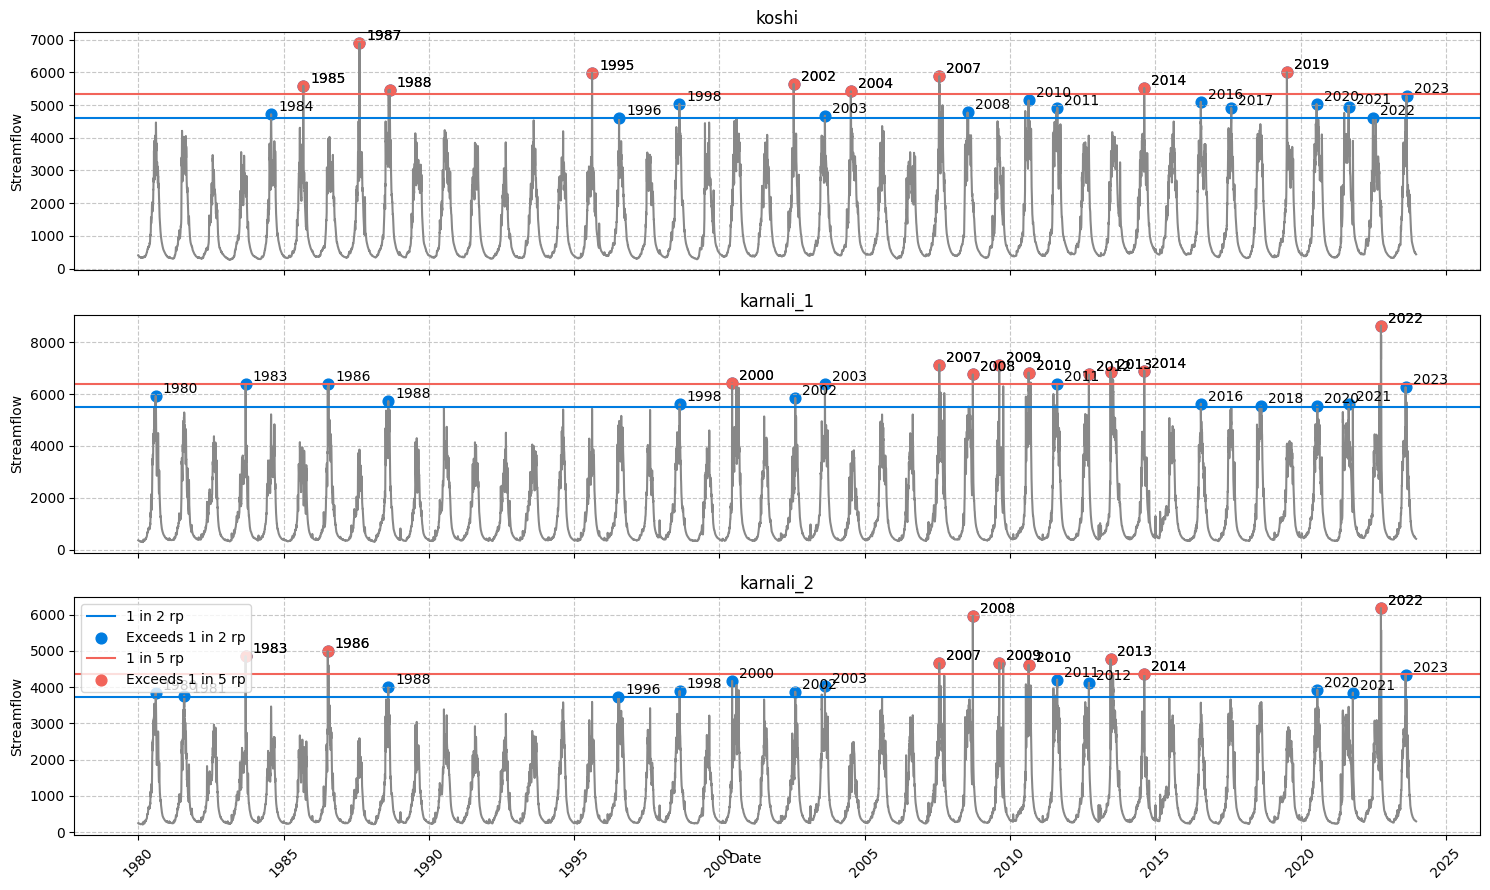

In [90]:
stations = df["station_name"].unique()
n_stations = len(stations)

n_cols = 1
n_rows = n_stations

rp_display = {2: SAPPHIRE, 5: TOMATO}

_fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(15, 3 * n_rows), sharex=True
)
axes = axes.flatten()

for i, _station in enumerate(stations):
    dff = df[df["station_name"] == _station].sort_values("valid_time")
    dff_peaks = df_peaks[df_peaks["station_name"] == _station]
    axes[i].plot(dff["valid_time"], dff["streamflow"], c=GREY_DARK)
    axes[i].set_title(_station)
    axes[i].set_ylabel("Streamflow")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(True, linestyle="--", alpha=0.7)

    for rp, c in rp_display.items():
        axes[i].axhline(rp_vals[rp][_station], c=c, label=f"1 in {rp} rp")
        mask = dff_peaks["sf_max"] >= rp_vals[rp][_station]
        axes[i].scatter(
            dff_peaks.loc[mask, "sf_max_date"],
            dff_peaks.loc[mask, "sf_max"],
            c=c,
            s=60,
            label=f"Exceeds 1 in {rp} rp",
        )

        for idx, row in dff_peaks.loc[mask].iterrows():
            year = row["sf_max_date"].year
            axes[i].annotate(
                f"{year}",
                (row["sf_max_date"], row["sf_max"]),
                xytext=(
                    5,
                    0,
                ),  # Offset text slightly above and to the right
                textcoords="offset points",
                ha="left",
                va="bottom",
                color="black",
                fontsize=10,
            )

_fig.text(0.5, 0.04, "Date", ha="center", va="center")
plt.legend()
plt.tight_layout()